# Project TicTacToe: REINFORCE vs Actor-Critic

This notebook directly compares the two algorithms I just learned:

- **REINFORCE (Monte Carlo policy gradient)**
- **Actor-Critic (policy + value baseline)**

Goal:
1. Train two agents over one environment TicTacToe.
2. Compare learning speed and consistency.
3. Evaluate over **100 game** with:
   - **Random opponent**
   - **Weak heuristic opponent**
4. Visualize:
   - training reward / win rate
   - entropy của policy
   - loss curve
   - action probabilities on some sample boards
   - replay a few sample matches

In [25]:
import math
import random
from collections import defaultdict
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import trange

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

sns.set_context("notebook")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 1) TicTacToe Environment

State Representation:
- The board is a 9-cell array, with values ​​in the range {-1, 0, +1}.
- Our agent always views the board from its own perspective:
  - Own cells: `+1`
  - Opponent cells: `-1`

Reward:
- Win: `+1`
- Lose: `-1`
- Tie: `0`
- Wrong move: Severe penalty

In [26]:

WIN_LINES = [
    (0, 1, 2), (3, 4, 5), (6, 7, 8),
    (0, 3, 6), (1, 4, 7), (2, 5, 8),
    (0, 4, 8), (2, 4, 6)
]

class TicTacToeEnv:
    def __init__(self):
        self.reset()

    def reset(self):
        self.board = np.zeros(9, dtype=np.int8)
        self.current_player = 1
        self.done = False
        self.winner = 0
        return self._get_obs(self.current_player)

    def _get_obs(self, player):
        return (self.board * player).astype(np.float32)

    def legal_actions(self):
        return np.where(self.board == 0)[0].tolist()

    def check_winner(self):
        for a, b, c in WIN_LINES:
            s = self.board[a] + self.board[b] + self.board[c]
            if s == 3:
                return 1
            if s == -3:
                return -1
        if np.all(self.board != 0):
            return 0
        return None

    def step(self, action):
        if self.done:
            raise ValueError("Game already finished.")
        if self.board[action] != 0:
            # invalid move => current player loses immediately
            self.done = True
            self.winner = -self.current_player
            reward = -1.0
            obs = self._get_obs(self.current_player)
            info = {"invalid": True}
            return obs, reward, self.done, info

        player = self.current_player
        self.board[action] = player
        result = self.check_winner()

        if result is not None:
            self.done = True
            self.winner = result
            if result == player:
                reward = 1.0
            elif result == 0:
                reward = 0.0
            else:
                reward = -1.0
            obs = self._get_obs(player)
            info = {"invalid": False}
            return obs, reward, self.done, info

        self.current_player *= -1
        obs = self._get_obs(self.current_player)
        reward = 0.0
        info = {"invalid": False}
        return obs, reward, self.done, info


def render_board(board):
    symbols = {1: "X", -1: "O", 0: "."}
    rows = []
    for i in range(0, 9, 3):
        rows.append(" ".join(symbols[int(x)] for x in board[i:i+3]))
    return "\n".join(rows)

## 2) Opponents: random và weak heuristic

Weak heuristics are very suitable as a baseline that is "weaker but not completely random":
1. If you can win immediately, choose the winning move.
2. If your opponent is about to win, block.
3. Prioritize the center.
4. Prioritize the corner.
5. Otherwise, random.

In [27]:

def find_winning_move(board, player):
    for a in np.where(board == 0)[0]:
        temp = board.copy()
        temp[a] = player
        for x, y, z in WIN_LINES:
            s = temp[x] + temp[y] + temp[z]
            if s == 3 * player:
                return int(a)
    return None


def random_opponent_action(env):
    return random.choice(env.legal_actions())


def weak_heuristic_action(env):
    board = env.board
    player = env.current_player
    opp = -player

    win_move = find_winning_move(board, player)
    if win_move is not None:
        return win_move

    block_move = find_winning_move(board, opp)
    if block_move is not None:
        return block_move

    if board[4] == 0:
        return 4

    corners = [i for i in [0, 2, 6, 8] if board[i] == 0]
    if corners:
        return random.choice(corners)

    return random.choice(env.legal_actions())


def mixed_opponent_action(env, p_weak=0.7):
    if random.random() < p_weak:
        return weak_heuristic_action(env)
    return random_opponent_action(env)

## 3) Policy network and Actor-Critic network

To make the code readable, we keep the model small:
- Input: 9 dimensions
- Hidden: 128
- Output policy: 9 logits
- Value head (with Actor-Critic): 1 scalar

When selecting an action, we always **mask** invalid cells.

In [28]:

class PolicyNet(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(9, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 9)
        )

    def forward(self, x):
        return self.net(x)


class ActorCriticNet(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(9, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.policy_head = nn.Linear(hidden, 9)
        self.value_head = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.body(x)
        logits = self.policy_head(h)
        value = self.value_head(h).squeeze(-1)
        return logits, value


def masked_categorical(logits, legal_actions):
    mask = torch.full_like(logits, -1e9)
    mask[..., legal_actions] = 0.0
    masked_logits = logits + mask
    return Categorical(logits=masked_logits), masked_logits


def state_tensor(state):
    return torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

## 4) Helpers: rollout, return, moving average, evaluation

In [29]:

def discounted_returns(rewards, gamma=0.99):
    out = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        out.append(G)
    out.reverse()
    return out


def moving_average(x, w=50):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode='valid')


def play_game_vs_opponent(select_action_fn, opponent_fn, agent_first=True, verbose=False):
    env = TicTacToeEnv()
    env.reset()
    agent_player = 1 if agent_first else -1
    timeline = []

    while not env.done:
        if env.current_player == agent_player:
            obs = env._get_obs(agent_player)
            action, extras = select_action_fn(obs, env.legal_actions())
            env.step(action)
            timeline.append((env.board.copy(), f"Agent->{action}", extras))
        else:
            action = opponent_fn(env)
            env.step(action)
            timeline.append((env.board.copy(), f"Opp->{action}", None))

    if env.winner == agent_player:
        outcome = 1
    elif env.winner == 0:
        outcome = 0
    else:
        outcome = -1

    if verbose:
        for board, text, extras in timeline:
            print(text)
            print(render_board(board))
            print("-" * 20)
        print("Outcome:", outcome)

    return outcome, timeline


def evaluate_agent(select_action_fn, opponent_fn, n_games=100):
    results = []
    for i in range(n_games):
        agent_first = (i % 2 == 0)
        outcome, _ = play_game_vs_opponent(select_action_fn, opponent_fn, agent_first=agent_first, verbose=False)
        results.append(outcome)
    wins = sum(r == 1 for r in results)
    draws = sum(r == 0 for r in results)
    losses = sum(r == -1 for r in results)
    return {
        "wins": wins,
        "draws": draws,
        "losses": losses,
        "win_rate": wins / n_games,
        "non_loss_rate": (wins + draws) / n_games,
    }

## 5) Train REINFORCE

Training design:
- Agents always learn from their own perspective.
- Opponents are a **mixed opponent** (mostly heuristic, occasionally random), making the learning process more varied.
- Rewards only become apparent at the end of the game.
- We add a slight **entropy bonus** to prevent policy collapse too early.

In [15]:

@dataclass
class ReinforceConfig:
    episodes: int = 4500
    gamma: float = 0.99
    lr: float = 1e-3
    entropy_coef: float = 0.01
    eval_every: int = 250


def train_reinforce(cfg=ReinforceConfig()):
    model = PolicyNet().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    stats = defaultdict(list)

    for ep in trange(cfg.episodes, desc="Training REINFORCE"):
        env = TicTacToeEnv()
        env.reset()
        agent_player = 1 if random.random() < 0.5 else -1

        log_probs = []
        entropies = []
        rewards = []
        invalid_count = 0

        while not env.done:
            if env.current_player == agent_player:
                obs = env._get_obs(agent_player)
                obs_t = state_tensor(obs)
                logits = model(obs_t)
                dist, _ = masked_categorical(logits, env.legal_actions())
                action = dist.sample()
                _, reward, done, info = env.step(int(action.item()))
                log_probs.append(dist.log_prob(action))
                entropies.append(dist.entropy())
                rewards.append(float(reward))
                invalid_count += int(info.get("invalid", False))
            else:
                opp_action = mixed_opponent_action(env, p_weak=0.7)
                _, opp_reward, done, info = env.step(opp_action)
                # reward from agent perspective
                rewards.append(float(-opp_reward) if done else 0.0)

        returns = discounted_returns(rewards, gamma=cfg.gamma)
        # only keep time-steps that agent has action
        # Because rewards has the opponent's turn included, we map by positions using log_probs
        agent_returns = []
        idx = 0
        env2 = TicTacToeEnv()
        env2.reset()
        env2.current_player = agent_player
        # simple reconstruction: pick reward indices when agent acted
        # easier and robust: recompute from stored action count positions
        action_indices = []
        env = TicTacToeEnv()
        env.reset()
        curr = agent_player if False else None
        # Instead of reconstructing via env, use a direct pass:
        # rewards list alternates according to actual turns, so agent actions occupy indices where turn==agent.
        turn = agent_player
        for i in range(len(rewards)):
            if turn == agent_player:
                action_indices.append(i)
            if rewards[i] != 0 or i < len(rewards)-1:
                turn *= -1
        # A safer method if game ended on current step: above still works because player switches conceptually only for sequencing.
        if len(action_indices) != len(log_probs):
            # fallback: align from the end
            action_indices = np.linspace(0, len(rewards)-1, num=len(log_probs), dtype=int).tolist()
        agent_returns = [returns[i] for i in action_indices]

        returns_t = torch.tensor(agent_returns, dtype=torch.float32, device=device)
        if len(returns_t) > 1:
            returns_t = (returns_t - returns_t.mean()) / (returns_t.std() + 1e-8)

        log_probs_t = torch.stack(log_probs)
        entropies_t = torch.stack(entropies)
        policy_loss = -(log_probs_t * returns_t).mean()
        entropy_loss = -entropies_t.mean()
        loss = policy_loss + cfg.entropy_coef * entropy_loss

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        final_reward = 1.0 if env.winner == agent_player else (0.0 if env.winner == 0 else -1.0)
        stats["episode_reward"].append(final_reward)
        stats["loss"].append(float(loss.item()))
        stats["entropy"].append(float(entropies_t.mean().item()))
        stats["invalid_moves"].append(invalid_count)

        if (ep + 1) % cfg.eval_every == 0:
            @torch.no_grad()
            def greedy_select(obs, legal_actions):
                logits = model(state_tensor(obs))
                dist, masked_logits = masked_categorical(logits, legal_actions)
                action = int(torch.argmax(masked_logits, dim=-1).item())
                probs = torch.softmax(masked_logits, dim=-1).squeeze(0).detach().cpu().numpy()
                return action, {"probs": probs}

            vs_rand = evaluate_agent(greedy_select, random_opponent_action, n_games=100)
            vs_weak = evaluate_agent(greedy_select, weak_heuristic_action, n_games=100)
            stats["eval_episode"].append(ep + 1)
            stats["eval_win_rate_random"].append(vs_rand["win_rate"])
            stats["eval_non_loss_random"].append(vs_rand["non_loss_rate"])
            stats["eval_win_rate_weak"].append(vs_weak["win_rate"])
            stats["eval_non_loss_weak"].append(vs_weak["non_loss_rate"])

    return model, stats

## 6) Train Actor-Critic

Actor-Critic uses:
- **actor loss**: `-log pi(a|s) * advantage`
- **critic loss**: MSE between `V(s)` and discounted return
- **advantage**: `G_t - V(s_t)`

This is usually more stable than Reinforce because the value head acts as a baseline.

In [31]:

@dataclass
class ActorCriticConfig:
    episodes: int = 4500
    gamma: float = 0.99
    lr: float = 1e-3
    entropy_coef: float = 0.01
    value_coef: float = 0.5
    eval_every: int = 250


def train_actor_critic(cfg=ActorCriticConfig()):
    model = ActorCriticNet().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    stats = defaultdict(list)

    for ep in trange(cfg.episodes, desc="Training Actor-Critic"):
        env = TicTacToeEnv()
        env.reset()
        agent_player = 1 if random.random() < 0.5 else -1

        log_probs = []
        entropies = []
        values = []
        rewards = []
        invalid_count = 0

        while not env.done:
            if env.current_player == agent_player:
                obs = env._get_obs(agent_player)
                obs_t = state_tensor(obs)
                logits, value = model(obs_t)
                dist, _ = masked_categorical(logits, env.legal_actions())
                action = dist.sample()
                _, reward, done, info = env.step(int(action.item()))
                log_probs.append(dist.log_prob(action))
                entropies.append(dist.entropy())
                values.append(value.squeeze(0))
                rewards.append(float(reward))
                invalid_count += int(info.get("invalid", False))
            else:
                opp_action = mixed_opponent_action(env, p_weak=0.7)
                _, opp_reward, done, info = env.step(opp_action)
                rewards.append(float(-opp_reward) if done else 0.0)

        returns = discounted_returns(rewards, gamma=cfg.gamma)

        action_indices = []
        turn = agent_player
        for i in range(len(rewards)):
            if turn == agent_player:
                action_indices.append(i)
            if rewards[i] != 0 or i < len(rewards)-1:
                turn *= -1
        if len(action_indices) != len(log_probs):
            action_indices = np.linspace(0, len(rewards)-1, num=len(log_probs), dtype=int).tolist()
        agent_returns = [returns[i] for i in action_indices]

        returns_t = torch.tensor(agent_returns, dtype=torch.float32, device=device)
        values_t = torch.stack(values)
        advantages = returns_t - values_t.detach()

        policy_loss = -(torch.stack(log_probs) * advantages).mean()
        value_loss = F.mse_loss(values_t, returns_t)
        entropy_loss = -torch.stack(entropies).mean()
        loss = policy_loss + cfg.value_coef * value_loss + cfg.entropy_coef * entropy_loss

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        final_reward = 1.0 if env.winner == agent_player else (0.0 if env.winner == 0 else -1.0)
        stats["episode_reward"].append(final_reward)
        stats["loss"].append(float(loss.item()))
        stats["policy_loss"].append(float(policy_loss.item()))
        stats["value_loss"].append(float(value_loss.item()))
        stats["entropy"].append(float(torch.stack(entropies).mean().item()))
        stats["invalid_moves"].append(invalid_count)

        if (ep + 1) % cfg.eval_every == 0:
            @torch.no_grad()
            def greedy_select(obs, legal_actions):
                logits, value = model(state_tensor(obs))
                dist, masked_logits = masked_categorical(logits, legal_actions)
                action = int(torch.argmax(masked_logits, dim=-1).item())
                probs = torch.softmax(masked_logits, dim=-1).squeeze(0).detach().cpu().numpy()
                return action, {"probs": probs, "value": float(value.item())}

            vs_rand = evaluate_agent(greedy_select, random_opponent_action, n_games=100)
            vs_weak = evaluate_agent(greedy_select, weak_heuristic_action, n_games=100)
            stats["eval_episode"].append(ep + 1)
            stats["eval_win_rate_random"].append(vs_rand["win_rate"])
            stats["eval_non_loss_random"].append(vs_rand["non_loss_rate"])
            stats["eval_win_rate_weak"].append(vs_weak["win_rate"])
            stats["eval_non_loss_weak"].append(vs_weak["non_loss_rate"])

    return model, stats

## 7) Run training

By default, it's geared towards average runtime. If you want it faster, decrease `TRAIN_EPISODES`; if you want a smoother learning path, increase it.

In [32]:

TRAIN_EPISODES = 4500  
EVAL_EVERY = 250

reinforce_cfg = ReinforceConfig(episodes=TRAIN_EPISODES, eval_every=EVAL_EVERY)
actor_critic_cfg = ActorCriticConfig(episodes=TRAIN_EPISODES, eval_every=EVAL_EVERY)

reinforce_model, reinforce_stats = train_reinforce(reinforce_cfg)
ac_model, ac_stats = train_actor_critic(actor_critic_cfg)

Training REINFORCE:   0%|          | 0/4500 [00:00<?, ?it/s]

Training Actor-Critic:   0%|          | 0/4500 [00:00<?, ?it/s]

## 8) Visualize training

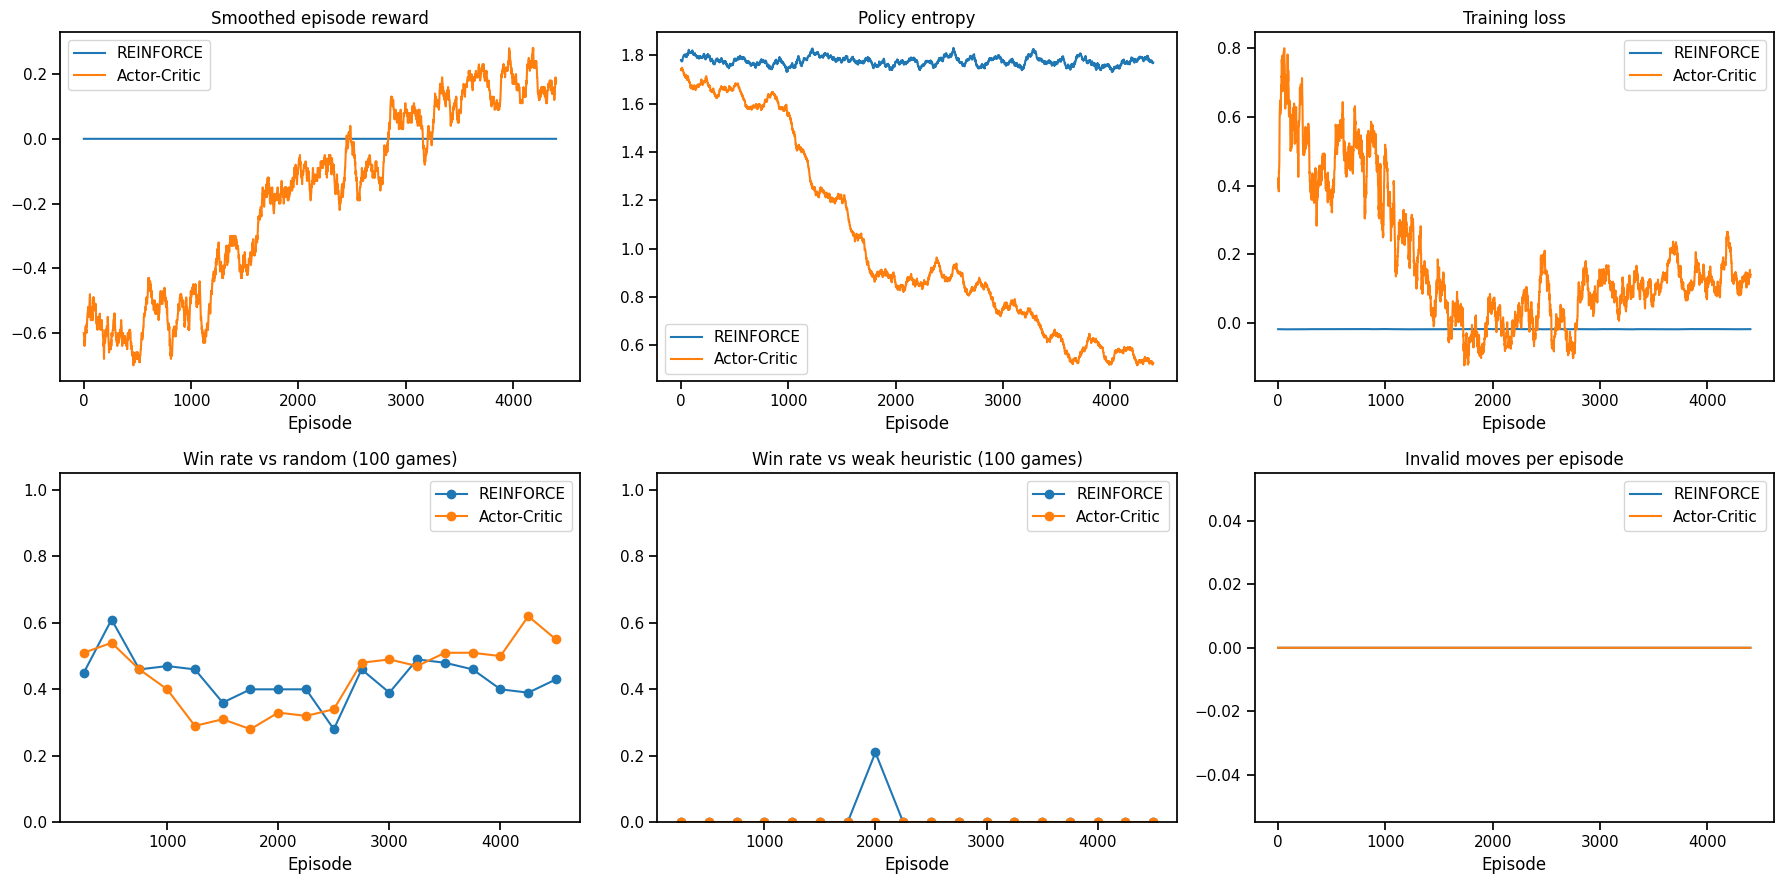

In [34]:

def plot_compare_stats(r_stats, ac_stats):
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))

    axes[0, 0].plot(moving_average(r_stats["episode_reward"], 100), label="REINFORCE")
    axes[0, 0].plot(moving_average(ac_stats["episode_reward"], 100), label="Actor-Critic")
    axes[0, 0].set_title("Smoothed episode reward")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].legend()

    axes[0, 1].plot(moving_average(r_stats["entropy"], 100), label="REINFORCE")
    axes[0, 1].plot(moving_average(ac_stats["entropy"], 100), label="Actor-Critic")
    axes[0, 1].set_title("Policy entropy")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].legend()

    axes[0, 2].plot(moving_average(r_stats["loss"], 100), label="REINFORCE")
    axes[0, 2].plot(moving_average(ac_stats["loss"], 100), label="Actor-Critic")
    axes[0, 2].set_title("Training loss")
    axes[0, 2].set_xlabel("Episode")
    axes[0, 2].legend()

    axes[1, 0].plot(r_stats["eval_episode"], r_stats["eval_win_rate_random"], marker='o', label="REINFORCE")
    axes[1, 0].plot(ac_stats["eval_episode"], ac_stats["eval_win_rate_random"], marker='o', label="Actor-Critic")
    axes[1, 0].set_title("Win rate vs random (100 games)")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylim(0, 1.05)
    axes[1, 0].legend()

    axes[1, 1].plot(r_stats["eval_episode"], r_stats["eval_win_rate_weak"], marker='o', label="REINFORCE")
    axes[1, 1].plot(ac_stats["eval_episode"], ac_stats["eval_win_rate_weak"], marker='o', label="Actor-Critic")
    axes[1, 1].set_title("Win rate vs weak heuristic (100 games)")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylim(0, 1.05)
    axes[1, 1].legend()

    axes[1, 2].plot(moving_average(r_stats["invalid_moves"], 100), label="REINFORCE")
    axes[1, 2].plot(moving_average(ac_stats["invalid_moves"], 100), label="Actor-Critic")
    axes[1, 2].set_title("Invalid moves per episode")
    axes[1, 2].set_xlabel("Episode")
    axes[1, 2].legend()

    plt.tight_layout()
    plt.show()

plot_compare_stats(reinforce_stats, ac_stats)

## 9) Final evaluation — 100 game vs random and weak heuristic

In [35]:

@torch.no_grad()
def reinforce_greedy(obs, legal_actions):
    logits = reinforce_model(state_tensor(obs))
    dist, masked_logits = masked_categorical(logits, legal_actions)
    action = int(torch.argmax(masked_logits, dim=-1).item())
    probs = torch.softmax(masked_logits, dim=-1).squeeze(0).cpu().numpy()
    return action, {"probs": probs}

@torch.no_grad()
def ac_greedy(obs, legal_actions):
    logits, value = ac_model(state_tensor(obs))
    dist, masked_logits = masked_categorical(logits, legal_actions)
    action = int(torch.argmax(masked_logits, dim=-1).item())
    probs = torch.softmax(masked_logits, dim=-1).squeeze(0).cpu().numpy()
    return action, {"probs": probs, "value": float(value.item())}

final_results = {
    "REINFORCE vs Random": evaluate_agent(reinforce_greedy, random_opponent_action, n_games=100),
    "REINFORCE vs Weak": evaluate_agent(reinforce_greedy, weak_heuristic_action, n_games=100),
    "Actor-Critic vs Random": evaluate_agent(ac_greedy, random_opponent_action, n_games=100),
    "Actor-Critic vs Weak": evaluate_agent(ac_greedy, weak_heuristic_action, n_games=100),
}

for name, res in final_results.items():
    print(name)
    print(res)
    print()

REINFORCE vs Random
{'wins': 36, 'draws': 10, 'losses': 54, 'win_rate': 0.36, 'non_loss_rate': 0.46}

REINFORCE vs Weak
{'wins': 0, 'draws': 5, 'losses': 95, 'win_rate': 0.0, 'non_loss_rate': 0.05}

Actor-Critic vs Random
{'wins': 55, 'draws': 38, 'losses': 7, 'win_rate': 0.55, 'non_loss_rate': 0.93}

Actor-Critic vs Weak
{'wins': 0, 'draws': 100, 'losses': 0, 'win_rate': 0.0, 'non_loss_rate': 1.0}



## 10) Look at the policy on some sample boards

The goal is to see how the network has learned to distribute the probability of action.

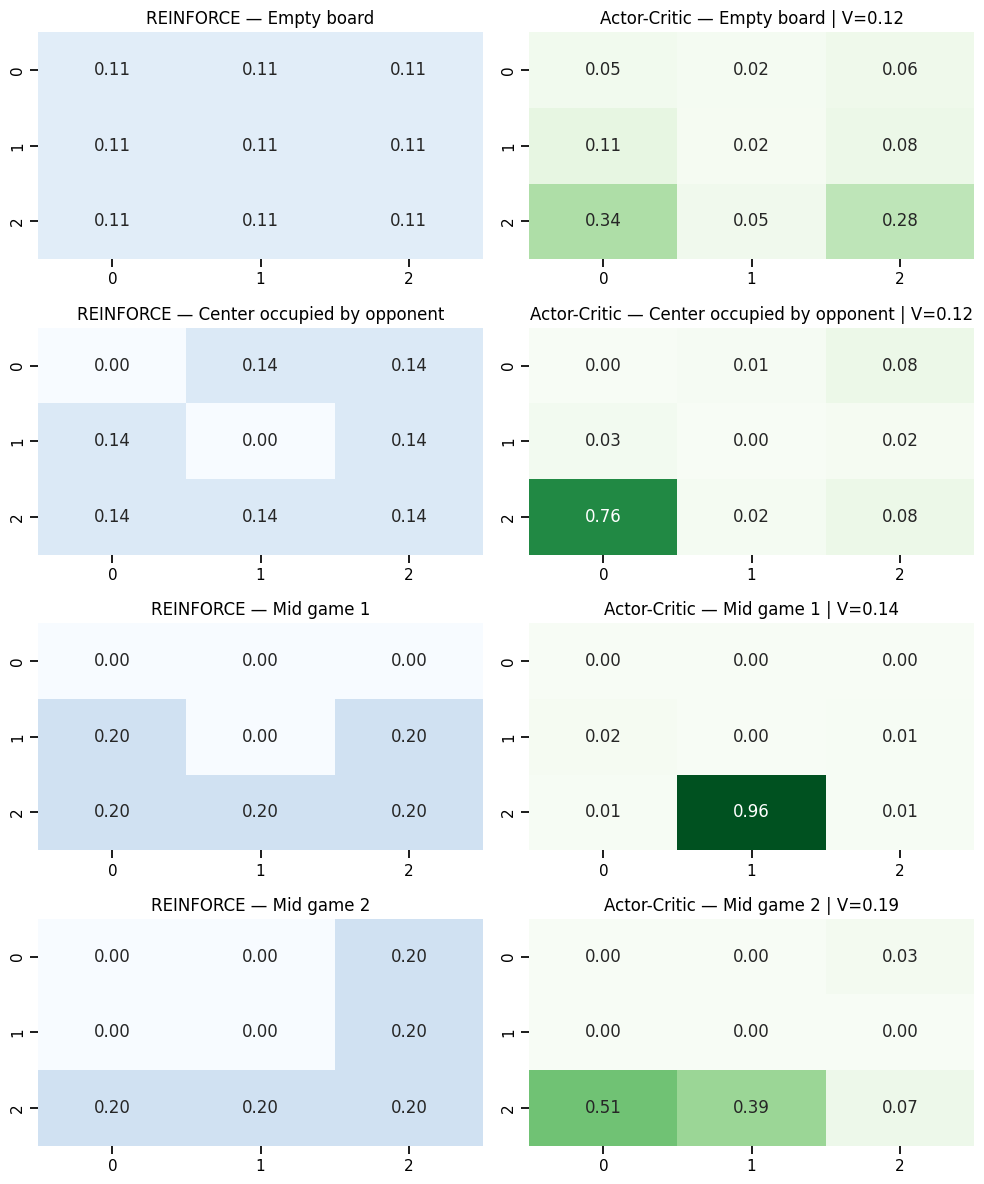

In [36]:

sample_states = [
    np.array([0,0,0,0,0,0,0,0,0], dtype=np.float32),
    np.array([1,0,0,0,-1,0,0,0,0], dtype=np.float32),
    np.array([1,-1,1,0,-1,0,0,0,0], dtype=np.float32),
    np.array([1,-1,0,1,-1,0,0,0,0], dtype=np.float32),
]

state_titles = [
    "Empty board",
    "Center occupied by opponent",
    "Mid game 1",
    "Mid game 2",
]

@torch.no_grad()
def policy_probs(model_like, state, actor_critic=False):
    legal = np.where(state == 0)[0].tolist()
    if actor_critic:
        logits, value = model_like(state_tensor(state))
        _, masked_logits = masked_categorical(logits, legal)
        probs = torch.softmax(masked_logits, dim=-1).squeeze(0).cpu().numpy()
        return probs, float(value.item())
    else:
        logits = model_like(state_tensor(state))
        _, masked_logits = masked_categorical(logits, legal)
        probs = torch.softmax(masked_logits, dim=-1).squeeze(0).cpu().numpy()
        return probs, None

fig, axes = plt.subplots(len(sample_states), 2, figsize=(10, 3 * len(sample_states)))
for i, (state, title) in enumerate(zip(sample_states, state_titles)):
    r_probs, _ = policy_probs(reinforce_model, state, actor_critic=False)
    ac_probs, value = policy_probs(ac_model, state, actor_critic=True)

    sns.heatmap(r_probs.reshape(3, 3), annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=axes[i, 0], vmin=0, vmax=1)
    axes[i, 0].set_title(f"REINFORCE — {title}")

    sns.heatmap(ac_probs.reshape(3, 3), annot=True, fmt=".2f", cmap="Greens", cbar=False, ax=axes[i, 1], vmin=0, vmax=1)
    axes[i, 1].set_title(f"Actor-Critic — {title} | V={value:.2f}")

plt.tight_layout()
plt.show()

## 11) Replay a few sample matches

In [37]:

def show_replays(select_fn, opponent_fn, title, n_replays=3):
    print("=" * 70)
    print(title)
    print("=" * 70)
    for k in range(n_replays):
        outcome, timeline = play_game_vs_opponent(select_fn, opponent_fn, agent_first=(k % 2 == 0), verbose=False)
        print(f"\nReplay {k+1} | outcome = {outcome}")
        for board, text, extras in timeline:
            print(text)
            print(render_board(board))
            if extras is not None and "probs" in extras:
                probs = np.array(extras["probs"]).reshape(3, 3)
                print("Policy probs:")
                print(np.round(probs, 2))
            print("-" * 20)

show_replays(ac_greedy, weak_heuristic_action, "Actor-Critic vs Weak Heuristic", n_replays=2)

Actor-Critic vs Weak Heuristic

Replay 1 | outcome = 0
Agent->6
. . .
. . .
X . .
Policy probs:
[[0.05 0.02 0.06]
 [0.11 0.02 0.08]
 [0.34 0.05 0.28]]
--------------------
Opp->4
. . .
. O .
X . .
--------------------
Agent->8
. . .
. O .
X . X
Policy probs:
[[0.06 0.   0.  ]
 [0.   0.   0.  ]
 [0.   0.01 0.93]]
--------------------
Opp->7
. . .
. O .
X O X
--------------------
Agent->1
. X .
. O .
X O X
Policy probs:
[[0. 1. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
--------------------
Opp->2
. X O
. O .
X O X
--------------------
Agent->0
X X O
. O .
X O X
Policy probs:
[[0.83 0.   0.  ]
 [0.16 0.   0.02]
 [0.   0.   0.  ]]
--------------------
Opp->3
X X O
O O .
X O X
--------------------
Agent->5
X X O
O O X
X O X
Policy probs:
[[0. 0. 0.]
 [0. 0. 1.]
 [0. 0. 0.]]
--------------------

Replay 2 | outcome = 0
Opp->4
. . .
. X .
. . .
--------------------
Agent->6
. . .
. X .
O . .
Policy probs:
[[0.03 0.   0.01]
 [0.   0.   0.  ]
 [0.59 0.   0.37]]
--------------------
Opp->2
. . X
. X .
O . .
